In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/project_1/customer_reviews_cleaned.csv')

In [ ]:
df.shape

(30840, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30840 entries, 0 to 30839
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   customer_id            30840 non-null  int64 
 1   product_id             30840 non-null  object
 2   product_title          30840 non-null  object
 3   star_rating            30840 non-null  int64 
 4   helpful_votes          30840 non-null  int64 
 5   total_votes            30840 non-null  int64 
 6   verified_purchase      30840 non-null  object
 7   review_date            30840 non-null  object
 8   sentiment              30840 non-null  int64 
 9   review_body_clean      30812 non-null  object
 10  review_headline_clean  30825 non-null  object
 11  year                   30840 non-null  int64 
 12  month                  30840 non-null  int64 
 13  month_name             30840 non-null  object
 14  seller_id              30840 non-null  object
dtypes: int64(7), object

In [ ]:
df['review_date'] = pd.to_datetime(df['review_date'])


In [ ]:
import re

def clean_review(text):
    if pd.isna(text):
        return text

    # Fix 'wordbr nextword' → 'word. next word'
    text = re.sub(r'(\w)br\s+', r'\1. ', text)

    # Remove any remaining standalone 'br'
    text = re.sub(r'\bbr\b', '', text)

    # Fix multiple spaces
    text = re.sub(r' {2,}', ' ', text)

    return text.strip()

df['review_body_clean'] = df['review_body_clean'].apply(clean_review)
df['review_headline_clean'] = df['review_headline_clean'].apply(clean_review)

In [ ]:
cols = [
    'customer_id', 'product_id', 'seller_id',   # ← side by side
    'product_title', 'star_rating', 'helpful_votes', 'total_votes',
    'verified_purchase', 'review_date', 'sentiment',
    'review_body_clean', 'review_headline_clean',
    'year', 'month', 'month_name'
]

df = df[cols]

In [ ]:
df.head()

,customer_id,product_id,seller_id,product_title,star_rating,helpful_votes,total_votes,verified_purchase,review_date,sentiment,review_body_clean,review_headline_clean,year,month,month_name
0,11555559,B00IKPX4GY,seller_2,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",5,0,0,Y,2015-08-31,1,great love it,five stars,2015,8,Aug
1,31469372,B00IKPYKWG,seller_3,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",3,0,0,N,2015-08-31,0,lots of ads. slow processing speed. occasional...,lots of ads slow processing speed occasionally...,2015,8,Aug
2,26843895,B00IKPW0UA,seller_1,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",5,0,0,Y,2015-08-31,1,excellent unit the versatility of this tablet ...,well thought out device,2015,8,Aug
3,19844868,B00LCHSHMS,seller_16,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",4,0,0,N,2015-08-31,1,i bought this on amazon prime so i ended up bu...,not all appsgames we were looking forward to u...,2015,8,Aug
4,1189852,B00IKPZ5V6,seller_4,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",5,0,0,Y,2015-08-31,1,all amazon products continue to meet my expect...,five stars,2015,8,Aug


#Analysis 1: Total Reviews
##Business Question
* How many total reviews exist?


In [ ]:
total_reviews = len(df)
print("Total Reviews:", total_reviews)

Total Reviews: 30840


In [ ]:
total_products = df['product_id'].nunique()
print("Total Sellers:", total_products)

Total Sellers: 21


##Analysis 2: Top 10 Sellers by Review Count
###Business Question

* Which sellers receive the most reviews?


In [ ]:
top_reviewed = (
    df.groupby('seller_id')
      .size()
      .sort_values(ascending=False)
      .head(10)
)

print(top_reviewed)

seller_id
seller_3     12153
seller_1      6271
seller_4      2399
seller_15     1759
seller_13     1755
seller_20     1160
seller_14     1126
seller_18      824
seller_5       819
seller_16      609
dtype: int64


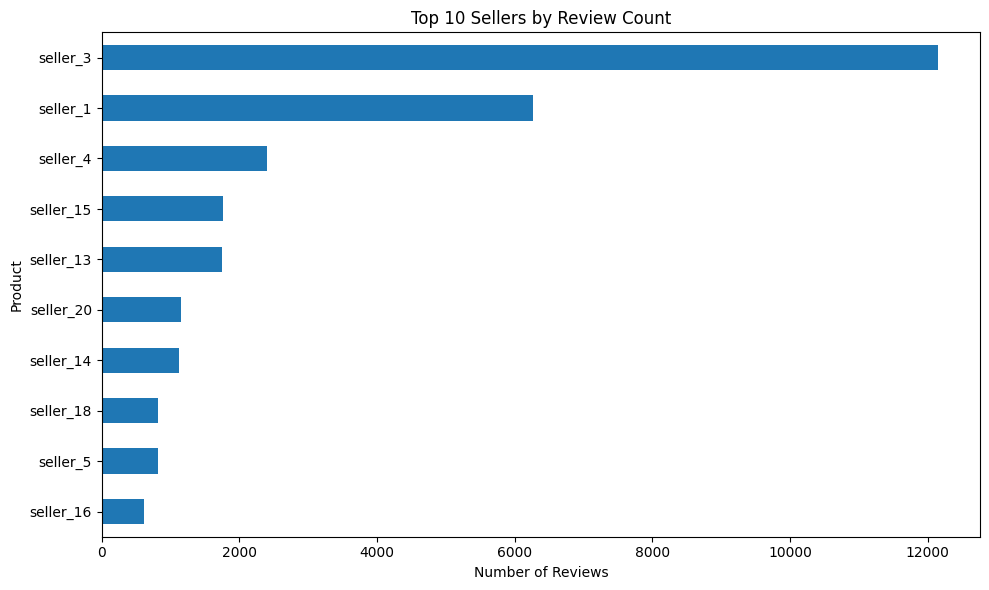

In [ ]:
#Visualization
import matplotlib.pyplot as plt

top_reviewed.plot(
    kind='barh',
    figsize=(10,6)
)
plt.gca().invert_yaxis()
plt.title("Top 10 Sellers by Review Count")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

##Business Insight

Product with **seller_3** accounts for the largest share of customer reviews, indicating strong sales volume and customer engagement. Any change in customer satisfaction for this product could significantly impact overall brand perception.

#Analysis 3: Top 10 Products with Highest Ratings
##Business Question

* Which products have the highest ratings?


In [ ]:
highest_rated = (
    df.groupby('seller_id')['star_rating']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(highest_rated)

seller_id
seller_13    4.516239
seller_21    4.513514
seller_20    4.494828
seller_11    4.487923
seller_14    4.475133
seller_16    4.463054
seller_15    4.445139
seller_18    4.425971
seller_1     4.355765
seller_10    4.355072
Name: star_rating, dtype: float64


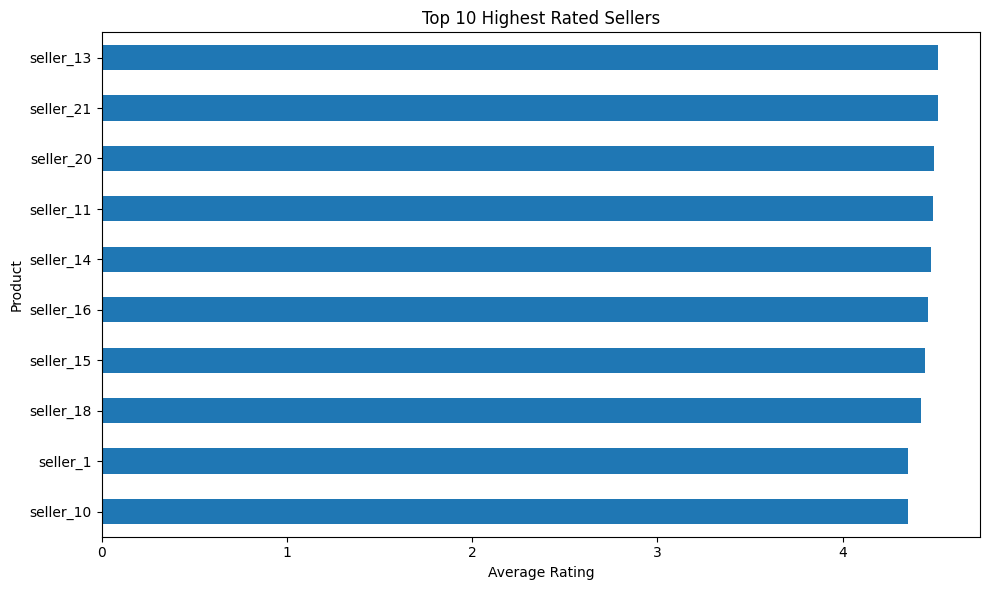

In [ ]:
#Visualization
highest_rated.plot(
    kind='barh',
    figsize=(10,6)
)
plt.gca().invert_yaxis()
plt.title("Top 10 Highest Rated Sellers")
plt.xlabel("Average Rating")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

##Business Insight

Several products maintain average ratings above 4.5 stars, suggesting strong product-market fit and positive customer experience.

#Analysis 4: Top 10 Products with Lowest Ratings
##Business Question

* Which products have the lowest ratings?


In [ ]:
lowest_rated = (
    df.groupby('seller_id')['star_rating']
      .mean()
      .sort_values()
      .head(10)
)

print(lowest_rated)

seller_id
seller_8     4.000000
seller_2     4.248538
seller_3     4.252859
seller_19    4.278689
seller_9     4.283361
seller_6     4.283582
seller_4     4.306794
seller_17    4.312000
seller_12    4.313869
seller_5     4.323565
Name: star_rating, dtype: float64


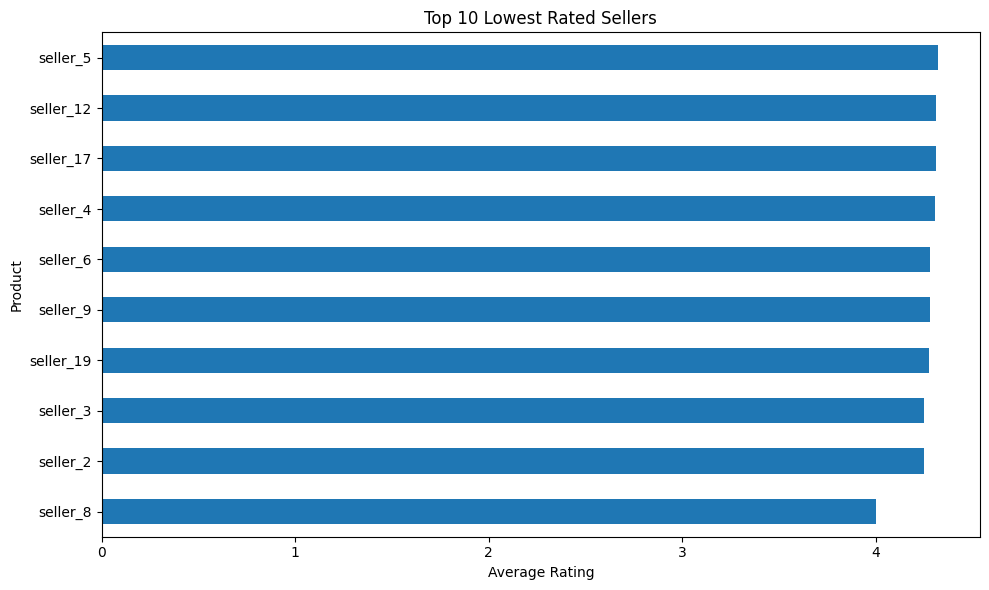

In [ ]:
#Visualization
lowest_rated.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Top 10 Lowest Rated Sellers")
plt.xlabel("Average Rating")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

#Analysis 5: Rating Distribution
##Business Question

* How are ratings distributed?

In [ ]:
rating_dist = df['star_rating'].value_counts().sort_index()
print(rating_dist)

star_rating
1     1707
2     1154
3     2216
4     5746
5    20017
Name: count, dtype: int64


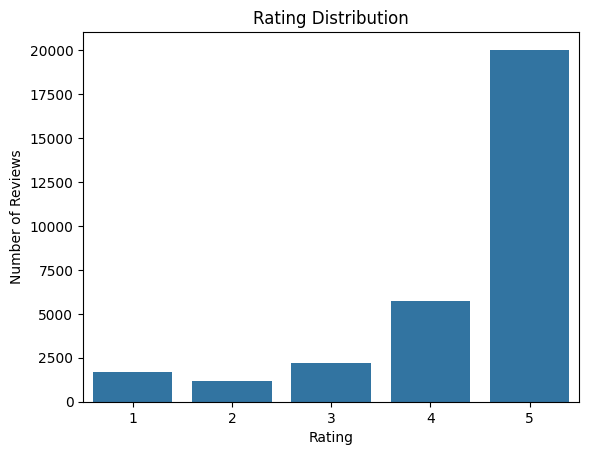

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='star_rating',
    data=df
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

##Business Insight

Ratings are heavily concentrated around 4 and 5 stars, indicating generally positive customer experiences.

#Analysis 6: Average Rating KPI

In [ ]:
avg_rating = round(df['star_rating'].mean(),2)

print(avg_rating)

4.34


#Analysis 7: Review Trend Over Time
##Business Question

How have reviews changed over time?

In [ ]:
df['review_date'] = pd.to_datetime(df['review_date'])

monthly_reviews = (
    df.set_index('review_date')
      .resample('M')
      .size()
)

print(monthly_reviews)

review_date
2014-10-31     552
2014-11-30    1045
2014-12-31    4223
2015-01-31    8015
2015-02-28    2708
2015-03-31    1978
2015-04-30    2283
2015-05-31    4136
2015-06-30    2219
2015-07-31    1862
2015-08-31    1819
Freq: ME, dtype: int64


/tmp/ipykernel_4850/1204268519.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


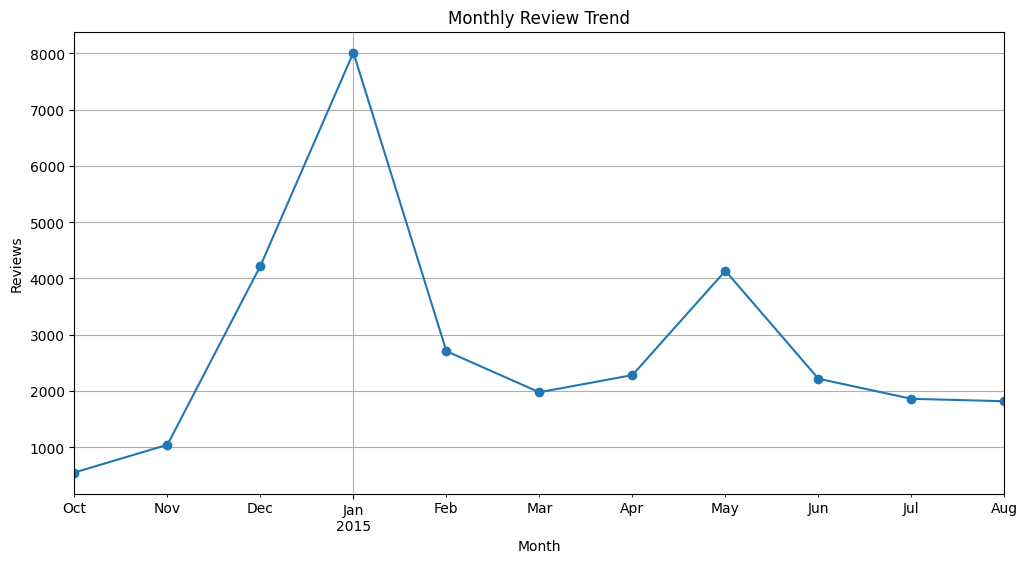

In [ ]:
monthly_reviews.plot(
    figsize=(12,6),
    marker='o'
)

plt.title("Monthly Review Trend")
plt.xlabel("Month")
plt.ylabel("Reviews")
plt.grid(True)
plt.show()

#Analysis 8: Monthly Average Rating Trend

In [ ]:
monthly_rating = (
    df.set_index('review_date')['star_rating']
      .resample('M')
      .mean()
)
print(monthly_rating)

review_date
2014-10-31    4.231884
2014-11-30    4.076555
2014-12-31    4.298366
2015-01-31    4.417467
2015-02-28    4.354136
2015-03-31    4.386754
2015-04-30    4.295226
2015-05-31    4.413201
2015-06-30    4.310951
2015-07-31    4.238453
2015-08-31    4.174272
Freq: ME, Name: star_rating, dtype: float64


/tmp/ipykernel_4850/735315211.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M')


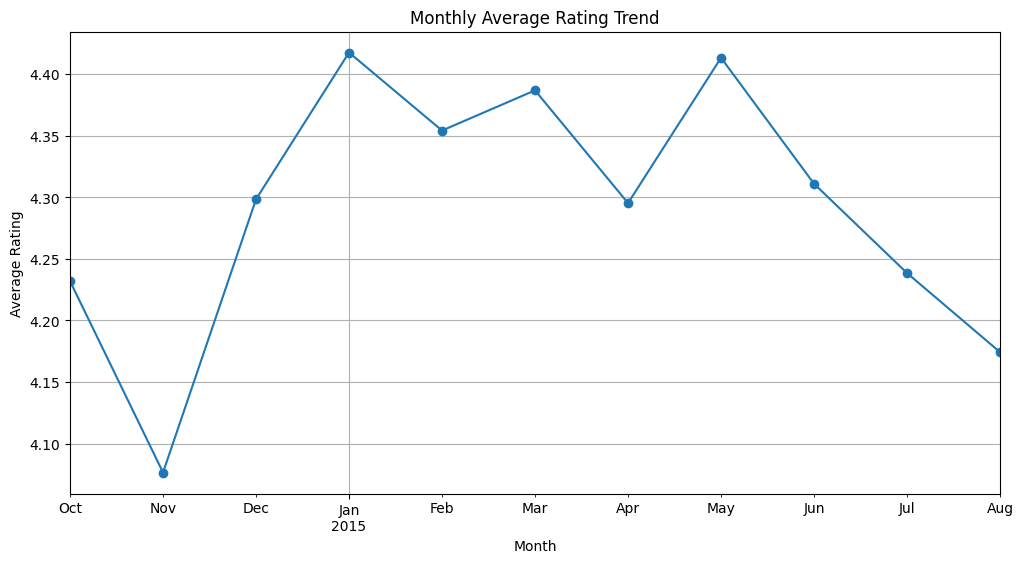

In [ ]:
monthly_rating.plot(
    figsize=(12,6),
    marker='o'
)

plt.title("Monthly Average Rating Trend")
plt.ylabel("Average Rating")
plt.xlabel("Month")
plt.grid(True)
plt.show()

##Overall Key Insights (Short Version)
Customer satisfaction is very high, with an average rating of 4.33 and 83.

1. 5% positive reviews.
2. seller_3 dominates customer activity, receiving 12,153 reviews (39% of all reviews), making it the most important seller to monitor.
3. seller_3 is a concern area because despite having the most reviews, its average rating (4.25) is lower than many competitors.
4. seller_13 is the best-performing seller, achieving the highest average rating (4.52) with a substantial review volume (1,755 reviews).
5. Review activity peaked in January 2015, generating 8,015 reviews, which is about 26% of all reviews.
6. Customer satisfaction also peaked during high activity periods, with ratings increasing from 4.08 (Nov 2014) to 4.42 (Jan 2015).

##Short Summary

The analysis of 30,839 customer reviews shows strong customer satisfaction, with an average rating of 4.33 and 83.5% positive reviews. Review activity is highly concentrated around seller_3, which generated 39% of all reviews, although its rating is lower than several competitors. Customer engagement reached its highest level in January 2015 (8,015 reviews), and customer ratings also improved during this period, suggesting successful business performance and positive customer experiences during peak demand.